# Introdução ao Aprendizado Supervisionado

## Libs

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error


# Calculando erros

## RMSE: Raiz quadrada da média dos erros quadráticos. Penaliza mais os erros maiores.m

In [3]:
# Valores reais e previstos
reais = [100000, 150000, 200000, 250000, 300000]
prev = [95000, 142000, 210000, 245000, 315000]

In [ ]:
# Cálculo do RMSE
mse = mean_squared_error(reais, prev)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

RMSE: 9370.165420097983


In [9]:
# Cálculo do RMSE, passo a passo:
print("1. Calcular os erros (diferença entre reais e previstos)")
erros = np.array(reais) - np.array(prev)
print(f"Erros: {erros}")

print("\n2. Elevar os erros ao quadrado")
erros_quadrados = erros ** 2
print(f"Erros ao quadrado: {erros_quadrados}")

print("\n3. Calcular a média dos erros ao quadrado (MSE)")
mse_calculado = np.mean(erros_quadrados)
print(f"MSE calculado: {mse_calculado}")

print("\n4. Tirar a raiz quadrada do MSE para obter o RMSE")
rmse_calculado = np.sqrt(mse_calculado)
print(f"RMSE calculado: {rmse_calculado}")

1. Calcular os erros (diferença entre reais e previstos)
Erros: [  5000   8000 -10000   5000 -15000]

2. Elevar os erros ao quadrado
Erros ao quadrado: [ 25000000  64000000 100000000  25000000 225000000]

3. Calcular a média dos erros ao quadrado (MSE)
MSE calculado: 87800000.0

4. Tirar a raiz quadrada do MSE para obter o RMSE
RMSE calculado: 9370.165420097983


## MAPE: Mean Absolute Percentage Error

In [10]:
# Cálculo do MAPE
mape = mean_absolute_percentage_error(reais, prev)
print(f"MAPE: {mape:.2%}")

MAPE: 4.47%


In [11]:
# Cálculo do MAPE, passo a passo:
print("\n1. Calcular os erros absolutos (diferença absoluta entre reais e previstos)")
erros_absolutos = np.abs(np.array(reais) - np.array(prev))
print(f"Erros absolutos: {erros_absolutos}")

print("\n2. Calcular os erros absolutos em relação aos valores reais (dividir pelos reais)")
erros_relativos = erros_absolutos / np.array(reais)
print(f"Erros relativos: {erros_relativos}")

print("\n3. Calcular a média dos erros relativos (MAPE)")
mape_calculado = np.mean(erros_relativos)
print(f"MAPE calculado: {mape_calculado:.2%}")


1. Calcular os erros absolutos (diferença absoluta entre reais e previstos)
Erros absolutos: [ 5000  8000 10000  5000 15000]

2. Calcular os erros absolutos em relação aos valores reais (dividir pelos reais)
Erros relativos: [0.05       0.05333333 0.05       0.02       0.05      ]

3. Calcular a média dos erros relativos (MAPE)
MAPE calculado: 4.47%


# Imputando valores faltantes

## Libs

In [13]:
# Imputação de dados faltantes usando SimpleImputer, que é uma técnica comum para lidar com valores ausentes em conjuntos de dados. O SimpleImputer pode ser configurado para substituir os valores faltantes por uma estratégia específica, como a média, mediana ou moda dos dados.
from sklearn.impute import SimpleImputer


In [17]:
dados = pd.DataFrame({
    'A': [1, 2, np.nan, 4, 5],
    'B': [np.nan, 1, 2, 3, 4],
    'C': [5, 4, np.nan, 2, 1]
})

In [19]:
print("Dados originais com valores faltantes:")
print(dados)
# Criar um SimpleImputer para substituir os valores faltantes pela média
imputer = SimpleImputer(strategy='mean')
# Aplicar o imputer aos dados
dados_imputados = imputer.fit_transform(dados)
print("\nDados após imputação de valores faltantes:")   
print(dados_imputados)

Dados originais com valores faltantes:
     A    B    C
0  1.0  NaN  5.0
1  2.0  1.0  4.0
2  NaN  2.0  NaN
3  4.0  3.0  2.0
4  5.0  4.0  1.0

Dados após imputação de valores faltantes:
[[1.  2.5 5. ]
 [2.  1.  4. ]
 [3.  2.  3. ]
 [4.  3.  2. ]
 [5.  4.  1. ]]


## Identificando Outliers

### Usando a distância Interquartil para detectar outliers

In [24]:
dados = np.array([1,2,3,4,5,100])
dados

array([  1,   2,   3,   4,   5, 100])

In [25]:
q1 = np.percentile(dados, 25)
q3 = np.percentile(dados, 75)
iqr = q3 - q1

In [26]:
print("Q1 (25º percentil):", q1)
print("Q3 (75º percentil):", q3)
print("IQR (Distância Interquartil):", iqr)

Q1 (25º percentil): 2.25
Q3 (75º percentil): 4.75
IQR (Distância Interquartil): 2.5


In [27]:
# Limite inferior e superior para detectar outliers
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

In [28]:
print("limite_inferior:", limite_inferior)
print("limite_superior:", limite_superior)

limite_inferior: -1.5
limite_superior: 8.5


In [29]:
outliers = np.where((dados < limite_inferior) | (dados > limite_superior))
print("Índices dos outliers:", outliers)

Índices dos outliers: (array([5]),)


## Remoção dos outliers

In [30]:
np.delete(dados, outliers)

array([1, 2, 3, 4, 5])

## Normalização dos dados de uma lista

In [31]:
from sklearn.preprocessing import normalize

In [33]:
dados = np.array([2,3,5,6,7,8,7,6,0])
dados

array([2, 3, 5, 6, 7, 8, 7, 6, 0])

In [35]:
dados_normalizados = normalize([dados], norm='max')
dados_normalizados

array([[0.25 , 0.375, 0.625, 0.75 , 0.875, 1.   , 0.875, 0.75 , 0.   ]])

## Padronização usando StandardScaler

In [1]:
# O standard scaler é uma técnica de normalização que transforma os dados para que tenham média zero e desvio padrão um. Ele é útil para algoritmos de machine learning que são sensíveis à escala dos dados, como regressão linear, SVM e redes neurais. O standard scaler é calculado usando a fórmula: z = (x - mean) / std, onde x é o valor original, mean é a média dos dados e std é o desvio padrão dos dados.
from sklearn.preprocessing import StandardScaler

In [3]:
dados = np.array([[1,2,3], [4,5,6], [7,8,9]])
dados

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [4]:
padronizador = StandardScaler()
dados_padronizados = padronizador.fit_transform(dados)
dados_padronizados

array([[-1.22474487, -1.22474487, -1.22474487],
       [ 0.        ,  0.        ,  0.        ],
       [ 1.22474487,  1.22474487,  1.22474487]])

## Categorizar dados usando o OneHotEncoder e LabelEncoder

In [8]:
# O One Hot Encoder é uma técnica de codificação usada para converter variáveis categóricas em um formato numérico que pode ser utilizado por algoritmos de machine learning. Ele cria uma nova coluna para cada categoria única na variável original, atribuindo um valor de 1 para a categoria presente e 0 para as categorias ausentes. Por exemplo, se tivermos uma variável "cor" com as categorias "vermelho", "verde" e "azul", o One Hot Encoder criará três colunas: "cor_vermelho", "cor_verde" e "cor_azul". Se a cor for "vermelho", a coluna "cor_vermelho" terá o valor 1, enquanto as colunas "cor_verde" e "cor_azul" terão o valor 0.
from sklearn.preprocessing import OneHotEncoder

# O LabelEncoder é uma técnica de codificação usada para converter variáveis categóricas em um formato numérico, atribuindo um número inteiro único para cada categoria. Ele é útil para algoritmos de machine learning que não conseguem lidar diretamente com variáveis categóricas, como regressão linear e SVM. O LabelEncoder é calculado usando a função fit_transform(), que ajusta o codificador aos dados e transforma as categorias em números inteiros. Por exemplo, se tivermos uma variável "cor" com as categorias "vermelho", "verde" e "azul", o LabelEncoder atribuirá 0 para "vermelho", 1 para "verde" e 2 para "azul".
from sklearn.preprocessing import LabelEncoder

### One hot encoder

In [9]:
cor = ['vermelho', 'verde', 'azul', 'vermelho', 'verde']
label_encoder = LabelEncoder()
cor_codificada = label_encoder.fit_transform(cor)
print("Categorias originais:", cor)
print("Categorias codificadas:", cor_codificada)

Categorias originais: ['vermelho', 'verde', 'azul', 'vermelho', 'verde']
Categorias codificadas: [2 1 0 2 1]


### Label Encoder

In [10]:
cor = ['vermelho', 'verde', 'azul', 'vermelho', 'verde']
label_encoder = LabelEncoder()
cor_codificada = label_encoder.fit_transform(cor)
print("Categorias originais:", cor)
print("Categorias codificadas:", cor_codificada)

Categorias originais: ['vermelho', 'verde', 'azul', 'vermelho', 'verde']
Categorias codificadas: [2 1 0 2 1]


## Cálculo das métricas de acurácia, precisão, recall e F1-score
Exemplo relacionado a testes médicos de COVID-19:
Imagine que temos um teste de diagnóstico para COVID-19 e uma população de 1000 pessoas, 200 estão realmente infectadas e 800 não estão.

Pessoas infectadas: 200
Pessoas não infectadas: 800

- Verdadeiros Positivos (VP): 150
- Verdadeiros Negativos (VN): 700
- Falsos Positivos (FP): 50
- Falsos Negativos (FN): 50

In [11]:
total = 1000
vp = 150
vn = 700
fp = 50
fn = 50

### Acuárcia: (VP + VN) / Total
A acurácia é a proporção de previsões corretas (tanto verdadeiros positivos quanto verdadeiros negativos) em relação ao total de casos. Um valor alto de acurácia indica que o modelo está fazendo previsões corretas na maioria dos casos.

In [12]:
acuracia = (vp + vn) / total
acuracia

0.85

### Precisão: VP / (VP + FP)
A precisão é a proporção de verdadeiros positivos em relação ao total de casos previstos como positivos (verdadeiros positivos + falsos positivos). Uma alta precisão indica que o modelo tem poucos falsos positivos.

In [16]:
precisao = vp / (vp + fp)
precisao

0.75

### Recall: VP / (VP + FN)
O recall, também conhecido como sensibilidade, é a proporção de verdadeiros positivos em relação ao total de casos realmente positivos (verdadeiros positivos + falsos negativos). Um alto recall indica que o modelo está capturando a maioria dos casos positivos.

In [18]:
recall = vp / (vp + fn)
recall

0.75

### F1-Score: 2 * (precisao * recall) / (precisao + recall)
O F1-score é a média harmônica entre precisão e recall. Ele é útil quando queremos um equilíbrio entre precisão e recall, especialmente em casos de classes desbalanceadas. Um F1-score alto indica que o modelo tem um bom desempenho tanto em termos de precisão quanto de recall.

In [19]:
f1_score = 2 * (precisao * recall) / (precisao + recall)
f1_score

0.75

In [20]:
## Calculando usando sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_real = [1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
y_prev = [1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
accuracy = accuracy_score(y_real, y_prev)
precision = precision_score(y_real, y_prev)
recall = recall_score(y_real, y_prev)
f1 = f1_score(y_real, y_prev)
print(f"Acurácia: {accuracy:.2%}")
print(f"Precisão: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1-Score: {f1:.2%}")

Acurácia: 90.00%
Precisão: 100.00%
Recall: 66.67%
F1-Score: 80.00%


In [22]:
## Outra forma é usando o classification_report do sklearn
from sklearn.metrics import classification_report
print(classification_report(y_real, y_prev))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.67      0.80         3

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10



## Matriz Confusão
A matriz de confusão é uma tabela que é usada para avaliar o desempenho de um modelo de classificação. Ela mostra o número de verdadeiros positivos (VP), verdadeiros negativos (VN), falsos positivos (FP) e falsos negativos (FN) que o modelo produziu. A matriz de confusão é útil para entender como o modelo está classificando os dados e para calcular métricas como acurácia, precisão, recall e F1-score.

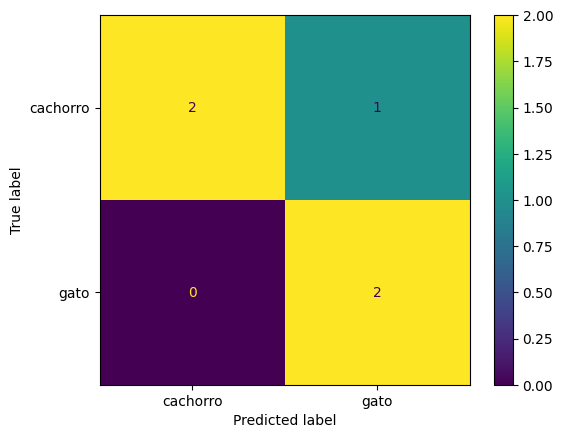

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_real_animal = ['cachorro', 'gato', 'cachorro', 'gato', 'cachorro']
y_prev_animal = ['cachorro', 'gato', 'gato', 'gato', 'cachorro']
cm = confusion_matrix(y_real_animal, y_prev_animal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['cachorro', 'gato'])
disp.plot()